### Create a graph where there are multiple nodes, each processing the state and updating it
* I will create 2 nodes that takes values and one of the sums it and the other multiplies it
* Both the nodes will take the result string from the state and concatenate their output to it

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    values : List[int]
    result : str

In [5]:
def addition_node(state : AgentState) -> AgentState:
    """Takes the state's values and adds them up"""
    output = sum(state['values'])
    state['result'] = f"The sum of values is {output}."

    return state

def product_node(state : AgentState) -> AgentState:
    """Takes the state's values and adds them up"""
    pdt = 1
    for x in state['values']:
        pdt = pdt * x 
    state['result'] = state['result'] + f" The product of values is {pdt}."

    return state

In [7]:
graph = StateGraph(AgentState)

graph.add_node("addition", addition_node)
graph.add_node("multiplication", product_node)

graph.add_edge(START, "addition")
graph.add_edge("addition", "multiplication")
graph.add_edge("multiplication", END)

app = graph.compile()

In [9]:
result = app.invoke({"values":[1, 2, 3, 4]})
result['result']

'The sum of values is 10. The product of values is 24.'

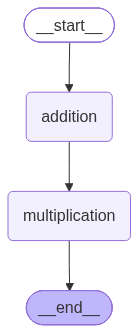

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
